In [340]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/Users/ikashkovskiy/Desktop/YANDEX P/data.csv')
#display(df.head(30)) #Открываем таблицу, визуально проверям состав таблицы
df.info() #Проверяем состав таблицы
#display(df.isna().sum()) #Проверяем пропущенные значения, присутствуют пропуски в двух колонках days_employed и total_income

#display(df[df['total_income'].isna()].head(25)) #Просмотр строк с пропущенными данными дает нам понять, что
#display(df[df['days_employed'].isna()].head(25)) #Строки совпадают

#days_employed_missed = 2174 / 21525 #Находим долю пропущенных значений
#total_income_missed = 2174 / 21525 
#print('Доля пропущенных значений в столбце days_employed равна: {:.1%}'.format(days_employed_missed) ,'Доля пропущенных значений в столбце total_income равна: {:.1%}' .format(total_income_missed), sep='\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


**Открыли таблицу**

1. Проверили значения
2. Нашли столбцы с пропущенными значениями:
    - days_employed (доля пропущенных значений 10,1%)
    - total_income (доля пропущенных значений 10,1%)

Возможные причины пропусков данных: ошибки при вводе/записи данных, респондент отказался их раскрывать или респондент не предоставил подтверждение этих данных.

**Заменить пропущенные данные медианными значениями лучше всего, замена на медианный показатель не так сильно повлияет на результат исследования, как замена например на 0 или среднестатистическое значение, которое может быть ближе к максимальным или минимальным значениям в столбце и серьезно изменить результат.**



In [341]:
columns_to_replace = ['days_employed', 'total_income'] 
for column in columns_to_replace:
    df['days_employed'] = df['days_employed'].fillna(df['days_employed'].median())
    df['total_income'] = df['total_income'].fillna(df['total_income'].median())

#df.isna().sum() #Проверка

### Проверим таблицу на артефакты и дубликаты

In [342]:
df['days_employed'].sort_values().unique() 
# отрицательные значения с множеством знаков после запятой и 
# подозрительно большие и мальнькие значения, если считать что это дни, но это могут быть часы.

array([-18388.94990057, -17615.56326563, -16593.47281726, ...,
       401675.09343386, 401715.81174889, 401755.40047533])

In [343]:
df['days_employed'] = df['days_employed'].abs() #уберем отрицательные значения

In [344]:
df['days_employed'] = df['days_employed'] / 365
#print(df['days_employed'].min(),df['days_employed'].max()) #получается кто то работал 22 дня, а кто то 1100 лет..
#значения этого столбца по заданию не очень важны в исследовании, но все равно приблизим их к реальности:
df.loc[(df.days_employed < 1), 'days_employed'] = df['days_employed'] *365 /12 #допустим что самые низкие показатели были в месяцах 
df.loc[(df.days_employed > 52), 'days_employed'] = df['days_employed'] /24 #допустим что 53 лет это максимальный стаж на работе, 
                                                                           #в 70 лет уже пора отдыхать: (17 (минимальный возраст в таблице) + 53 = 70 лет)

print(df['days_employed'].min(),df['days_employed'].max()) #осталось округлить

df['days_employed'] = df['days_employed'].astype(int)
df['total_income'] = df['total_income'].astype(int) # сразу же меняем тип значений столбца total_income по заданию

#print(df['days_employed'].min(),df['days_employed'].max()) #проверка
#print(df['total_income'].min(),df['total_income'].max()) #проверка

1.0008400273011608 50.38068465909146


In [345]:
df['days_employed'] = df['days_employed'].astype(int)
df['total_income'] = df['total_income'].astype(int)

In [346]:
# переименуем колонку 'days_employed' на 'years_employed', так будет нагляднее.
df = df.rename(columns={
  'days_employed' : 'years_employed',
})

In [347]:
df['children'].sort_values().unique() #Проверяем уникальные значения в столбце "количество детей"

array([-1,  0,  1,  2,  3,  4,  5, 20])

In [348]:
#df['children'].value_counts() #нашел способ найти их быстрее

In [349]:
df[df['children'] == -1]['children'].count() #Считаем количество "подозрительных" значений

47

In [350]:
df[df['children'] == 20]['children'].count() #Считаем количество "подозрительных" значений 

76

Итак, видим что в столбцах "children" есть отрицательные значения и очень большое число детей равное 20, 
скорее всего это ошибка ввода данных и проверка количества таких значений это подтвердила: 
- 47 значений "-1" ребенок 
- 76 значений "20" детей


Ниже изменим эти значения на "1" и "2" соответственно:  

In [351]:
df.loc[df.children == -1, 'children'] = 1 #Заменяем -1 на 1
df.loc[df.children == 20, 'children'] = 2 #Заменяем 20 на 2
#df['children'].unique() #Проверка

In [352]:
df['dob_years'].sort_values().unique() #Проверяем уникальные значения в столбце "возраст"

array([ 0, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75])

In [353]:
df[df['dob_years'] == 0 ]['dob_years'].count()

101

In [354]:
#display(df[df['dob_years'] == 0].head(25)) #Проверяем по типу занятости клиента строки с 0 в столбце "возраст"

При проверке возраста выявил значения 0 у 101 клиента, по типу занятости видим что, это эти клиенты могут иметь 
различные типы занятости 

(То есть это неоднородные клиенты по типу занятости, которым можно задать какое то среднее или медианное значение без изменений возможных изменений в результате) 

Но так как их доля в данных всего: 101 / 21525 * 100 = 0,46% ими можно "пожертвовать" и удалить строки с нулевым возрастом совсем, что бы они не размывали возраст в дальнейщем исследовании.

In [355]:
df = df[df.dob_years != 0]
#df[df['dob_years'] == 0 ]['dob_years'].count() #Проверка

In [356]:
df['education_id'].unique() #Видим 5 вариантов для столбца 'education'

array([0, 1, 2, 3, 4])

In [357]:
df['education'].sort_values().unique() #часть значений дублируется, 
                         #необходимо привезти их в соответствие с количеством вариантов в 'education_id' 

array(['ВЫСШЕЕ', 'Высшее', 'НАЧАЛЬНОЕ', 'НЕОКОНЧЕННОЕ ВЫСШЕЕ',
       'Начальное', 'Неоконченное высшее', 'СРЕДНЕЕ', 'Среднее',
       'УЧЕНАЯ СТЕПЕНЬ', 'Ученая степень', 'высшее', 'начальное',
       'неоконченное высшее', 'среднее', 'ученая степень'], dtype=object)

Упорядочим варианты образования:
- Начальное
- Среднее
- Неоконченное высшее
- Высшее
- Ученая степень

In [358]:
df['education'] = df['education'].replace(('начальное', 'НАЧАЛЬНОЕ'), 'Начальное')
df['education'] = df['education'].replace(('СРЕДНЕЕ', 'среднее'), 'Среднее')
df['education'] = df['education'].replace(('высшее', 'ВЫСШЕЕ'), 'Высшее')
df['education'] = df['education'].replace(('неоконченное высшее', 'НЕОКОНЧЕННОЕ ВЫСШЕЕ'), 'Неоконченное высшее')
df['education'] = df['education'].replace(('ученая степень', 'УЧЕНАЯ СТЕПЕНЬ'), 'Ученая степень')

df['education'].unique() #Проверяем

array(['Высшее', 'Среднее', 'Неоконченное высшее', 'Начальное',
       'Ученая степень'], dtype=object)

In [359]:
df['gender'].unique()
#df[df['gender'] == 'XNA']['gender'].count() #видим странный пол 'XNA'

array(['F', 'M', 'XNA'], dtype=object)

In [360]:
df[df['gender'] == 'XNA' ]['gender'].count() #строка с таким значением только одна, удалим ее
df = df[df.gender != 'XNA'] 
#df[df['gender'] == 'XNA' ]['gender'].count() #проверка

In [361]:
#df['income_type'].sort_values().unique() #все в норме

In [362]:
df['purpose'].sort_values().unique()

#display(df['purpose'].value_counts()) #визуализация дубликатов

array(['автомобили', 'автомобиль', 'высшее образование',
       'дополнительное образование', 'жилье',
       'заняться высшим образованием', 'заняться образованием',
       'на покупку автомобиля', 'на покупку подержанного автомобиля',
       'на покупку своего автомобиля', 'на проведение свадьбы',
       'недвижимость', 'образование', 'операции с жильем',
       'операции с коммерческой недвижимостью',
       'операции с недвижимостью', 'операции со своей недвижимостью',
       'покупка жилой недвижимости', 'покупка жилья',
       'покупка жилья для сдачи', 'покупка жилья для семьи',
       'покупка коммерческой недвижимости', 'покупка недвижимости',
       'покупка своего жилья', 'получение высшего образования',
       'получение дополнительного образования', 'получение образования',
       'приобретение автомобиля', 'профильное образование',
       'ремонт жилью', 'свадьба', 'свой автомобиль',
       'сделка с автомобилем', 'сделка с подержанным автомобилем',
       'строительство 

In [363]:
#print(df.duplicated().sum()) #Проверяем сколько дубликатов в данных
df = df.drop_duplicates().reset_index(drop=True) 
#удаляем дубликаты (с удалением старых индексов и формированием новых)
#print(df.duplicated().sum()) #Проверяем результат
#df.tail()

**В первой части:**

1. Выполнили проверку предоставленных данных.  
2. Заполнили пропуски в "days_employed" - теперь "years_employed" и "total_income" медианными значениями, по условию задачи.
3. Удалили строки с не представляющими ценности "испорченными" данными в столбцах "dob_years" и "gender"
4. Очистили от неявных дубликатов столбец "education"
5. Удалили явные дубликаты
6. Поменяли типы данных в двух столбцах "years_employed" и "total_income" для наглядности данных и по условию задачи


In [364]:
df_education_id = df[['education_id', 'education']]
#df_education_id.info() #проверка
#df_education_id.tail()

In [365]:
df_family_status_id = df[['family_status_id', 'family_status']]

In [366]:
df = df.drop(['family_status', 'education'], axis=1)
#df.info() #проверка

In [367]:
df.insert(9, 'total_income_category', 0) #добавляем столбец с категориями заработка по условию задания
def income(income):
    if income <= 30000:
        return  'E'
    elif income <= 50000:
        return 'D'
    elif income <= 200000:
        return 'C'
    elif income <= 1000000:
        return 'B'    
    else:
        return 'A'   
    
df['total_income_category'] = df['total_income'].apply(income)

In [368]:
#df[df['total_income_category'] == 'A']['total_income_category'].count() #проверка миллионеров

In [369]:
df.insert(11, 'purpose_category', 0) #добавляем столбец 'purpose_category'

In [370]:
df['purpose_category'] = df['purpose'] 

#передаем значения столбца 'purpose' столбцу 'purpose_category', что бы потом заменить их

In [371]:
df['purpose'].sort_values().unique() 
#видим что "цели" подходящие под более широкую категорию, которую мы будем обозначать содержат однокоренные слова:
# "движ" и "жил" для категории "операции с недвижимостью"; 
# По этому заменим все строки в столбце содержащие определенный корень на название более общей категории из задания

array(['автомобили', 'автомобиль', 'высшее образование',
       'дополнительное образование', 'жилье',
       'заняться высшим образованием', 'заняться образованием',
       'на покупку автомобиля', 'на покупку подержанного автомобиля',
       'на покупку своего автомобиля', 'на проведение свадьбы',
       'недвижимость', 'образование', 'операции с жильем',
       'операции с коммерческой недвижимостью',
       'операции с недвижимостью', 'операции со своей недвижимостью',
       'покупка жилой недвижимости', 'покупка жилья',
       'покупка жилья для сдачи', 'покупка жилья для семьи',
       'покупка коммерческой недвижимости', 'покупка недвижимости',
       'покупка своего жилья', 'получение высшего образования',
       'получение дополнительного образования', 'получение образования',
       'приобретение автомобиля', 'профильное образование',
       'ремонт жилью', 'свадьба', 'свой автомобиль',
       'сделка с автомобилем', 'сделка с подержанным автомобилем',
       'строительство 

In [372]:
df.loc[df['purpose_category'].str.contains('авто'), 'purpose_category'] = 'операции с автомобилем'
df.loc[df['purpose_category'].str.contains('свад'), 'purpose_category'] = 'проведение свадьбы'
df.loc[df['purpose_category'].str.contains('недвиж'), 'purpose_category'] = 'операции с недвижимостью'
df.loc[df['purpose_category'].str.contains('жил'), 'purpose_category'] = 'операции с недвижимостью'
ss
df['purpose_category'].unique()

array(['операции с недвижимостью', 'операции с автомобилем',
       'получение образования', 'проведение свадьбы'], dtype=object)

In [373]:

#так я решал зачачу категоризации до прохождения урока..

#data = df['purpose']
#stack = pd.DataFrame(data = data, columns = ['purpose'])

# функция присваивает новое значение ячейки в зависимости от ее содержания

#def purpose_rename(row):
#    if 'авто' in row['purpose']: 
#        return 'операции с автомобилем'
#    elif 'свад' in row['purpose']:
#        return 'проведение свадьбы'
#    elif 'недвиж' in row['purpose']:
#        return 'операции с недвижимостью'
#    elif 'жил' in row['purpose']:
#        return 'операции с недвижимостью'
#    elif 'образо' in row['purpose']:
#        return 'получение образования'
#    else:
#        return 'other'

#df['purpose_category'] = df.apply(purpose_rename, axis=1)


In [374]:
#df['purpose_category'].unique() #проверяем

In [375]:
#Еще пробовал так, но это совсем долго и не красиво, но тоже работает:

#df['purpose_category'] = df['purpose_category'].replace(('на покупку своего автомобиля', 'автомобиль', 'сделка с подержанным автомобилем', 'на покупку подержанного автомобиля', 'свой автомобиль', 'автомобили', 'на покупку автомобиля', 'сделка с автомобилем', 'приобретение автомобиля'), 'операции с автомобилем') 
#df['purpose_category'] = df['purpose_category'].replace(('операции с недвижимостью', 'покупка коммерческой недвижимости', 'покупка жилья для сдачи', 'операции с коммерческой недвижимостью','операции с жильем', 'покупка жилья', 'жилье', 'покупка жилья для семьи', 'строительство собственной недвижимости','операции со своей недвижимостью', 'недвижимость', 'строительство жилой недвижимости', 'строительство недвижимости', 'покупка недвижимости', 'покупка своего жилья','ремонт жилью', 'строительство недвижимости', 'покупка жилой недвижимости'), 'операции с недвижимостью')
#df['purpose_category'] = df['purpose_category'].replace(('свадьба', 'на проведение свадьбы', 'сыграть свадьбу'), 'проведение свадьбы')
#df['purpose_category'] = df['purpose_category'].replace(('заняться высшим образованием', 'дополнительное образование', 'высшее образование', 'получение дополнительного образования','образование', 'профильное образование', 'получение высшего образования', 'заняться образованием'), 'получение образования')
#df['purpose_category'].unique() #проверяем

**Ответы на вопросы :**

In [376]:
#Есть ли зависимость между количеством детей и возвратом кредита в срок?

#df['debt'].unique() #судя по значениям: 0 - отсутсвие задолженности, а 1 - наличие долга

df.groupby('debt')['debt'].count().sort_values(ascending=False) #долги есть у 1733 заемшиков

debt
0    19619
1     1733
Name: debt, dtype: int64

In [377]:
# проверяем завсимость наличия долгов и колличества детей и считаем отношение:
display(df.groupby('children').agg({'debt': ['size','sum', 'mean']}))

# у заемщиков с 1, 2, 3 и 4 детьми показатель хуже всего,
# без детей и с 5 детьми (сложно учитывать таких заемщиков, ведь их всего 9) 
# меньше всего долгов в общем выражении.

debt                
           size   sum      mean
children                       
0         14021  1058  0.075458
1          4839   442  0.091341
2          2114   202  0.095553
3           328    27  0.082317
4            41     4  0.097561
5             9     0  0.000000

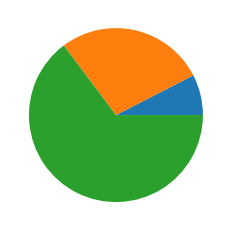

In [378]:
plt.pie([7.545, 27.69, 64.765 ])
plt.show()

# зеленый - без просроченных платежей
# оранжевый - без детей и просроченными платежами
# синий - с детьми и просроченными платежами

**Есть ли зависимость между количеством детей и возвратом кредита в срок?**

***Да, конкретная зависимость прослеживается***

- Заемщики с детьми имеют больщую долю просроченной задолженности

In [379]:
# Есть ли зависимость между семейным положением и возвратом кредита в срок?

family_grouped = df.groupby('family_status_id').agg({'debt': ['count', 'sum']})
family_grouped['conversion'] = family_grouped['debt']['sum'] / family_grouped['debt']['count'] 
display(family_grouped)

#display(df.groupby('family_status_id').agg({'debt': ['size','sum', 'mean']}))  #тоже самое, но одной строкой

# самый низкий показатель просроченной задолженности у: 
# не женатых / не замужних, 
# вдов /вдовцов и 
# состоящих в гражданском браке
# самый высокий показтель у женатых /замужних и разведенных заемщиков

debt      conversion
                  count  sum           
family_status_id                       
0                 12290  927   0.075427
1                  4129  386   0.093485
2                   954   62   0.064990
3                  1185   85   0.071730
4                  2794  273   0.097709

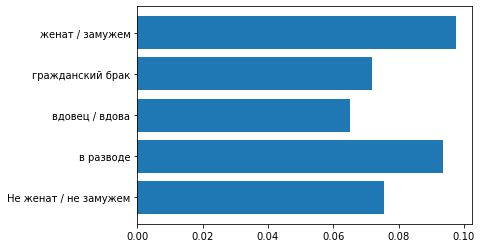

In [380]:
plt.barh(['Не женат / не замужем', 'в разводе', 'вдовец / вдова', 'гражданский брак', 'женат / замужем'], 
         [0.075427, 0.093485, 0.064990, 0.071730, 0.097709])
plt.show()

**Есть ли зависимость между семейным положением и возвратом кредита в срок?**

***Да, конкретная зависимость прослеживается***

- Самый высокий показтель просроченной задолженности у женатых / замужних и разведенных заемщиков

In [381]:
# Есть ли зависимость между уровнем дохода и возвратом кредита в срок?

display(df.groupby('total_income_category').agg({'debt': ['size','sum', 'mean']})) 

debt                
                        size   sum      mean
total_income_category                       
A                         25     2  0.080000
B                       5014   355  0.070802
C                      15943  1353  0.084865
D                        348    21  0.060345
E                         22     2  0.090909

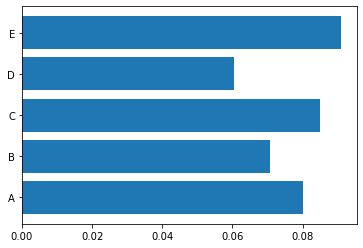

In [382]:
plt.barh(['A', 'B', 'C', 'D', 'E'], [0.080000,0.070802, 0.084865, 0.060345, 0.090909])
#plt.barh(['A', 'B', 'C', 'D', 'E'], [2, 355, 1353, 21, 2])
plt.show()

**Есть ли зависимость между уровнем дохода и возвратом кредита в срок?**

***Да, конкретная зависимость прослеживается***

- Самый высокий показтель просроченной задолженности у заемщиков со средним доходом, а у заемщиков с доходом ниже среднего доля задолженности ниже - им можно доверять, они достаточно ответственные плательщики 

In [383]:
# Как разные цели кредита влияют на его возврат в срок?

display(df.groupby('purpose_category').agg({'debt': ['size','sum', 'mean']})) 


debt               
                           size  sum      mean
purpose_category                              
операции с автомобилем     4284  400  0.093371
операции с недвижимостью  10763  779  0.072378
получение образования      3995  370  0.092616
проведение свадьбы         2310  184  0.079654

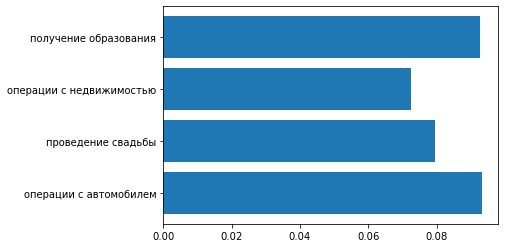

In [384]:
plt.barh(['операции с автомобилем', 'проведение свадьбы', 'операции с недвижимостью', 'получение образования'],
        [0.093371,0.079654, 0.072378, 0.092616])
plt.show()

**Как разные цели кредита влияют на его возврат в срок?**

***Да, конкретная зависимость прослеживается***

- Самый высокий показтель просроченной задолженности у заемщиков на автомобили и образование, а у заемщиков на операции с недвижимостью и свадьбу меньше вероятность накопления долгов.

 **ВЫВОД**

**Самые лучшие показатели у заещиков на операции с недвижимостью без детей, не замужних / не женатых и с заработком выше среднего**

**Самые худшие показатели у заещиков на образование, с детьми, со средним доходом, разведенных и замужних/женатых**